## Poverty NN activation sweep (step-by-step)

This notebook reproduces what we did in a **sequential**, explain-as-we-go workflow:

- Build `poverty_lag1` from the panel data
- Time split (train `<=2020`, test `>=2021`)
- Baseline evaluation (`poverty_lag1`)
- PyTorch MLP training with early stopping
- Activation/architecture sweep and result table


### Imports

In [3]:
import pandas as pd
import numpy as np
import torch
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

## Step 1 — Load data + build the lag feature

We use `data/processed/panel/marz_year_panel_full.csv`, then compute:

- `poverty_lag1` = previous year’s `poverty_rate` within each `marz`.

This is the same baseline idea you used in the notebook for forecasting.


In [4]:
DATA_PATH = "../data/processed/panel/marz_year_panel_full.csv"

df = pd.read_csv(DATA_PATH)
df = df.sort_values(["marz", "year"]).copy()
df["poverty_lag1"] = df.groupby("marz")["poverty_rate"].shift(1)

print("rows, cols:", df.shape)
print("year min/max:", df["year"].min(), df["year"].max())
df[["marz", "year", "poverty_rate", "poverty_lag1"]].head(12)


rows, cols: (187, 25)
year min/max: 2008 2024


,marz,year,poverty_rate,poverty_lag1
1,Aragatsotn,2008,20.3,NaN
12,Aragatsotn,2009,25.4,20.3
23,Aragatsotn,2010,28.9,25.4
34,Aragatsotn,2011,20.7,28.9
45,Aragatsotn,2012,21.2,20.7
56,Aragatsotn,2013,22.7,21.2
67,Aragatsotn,2014,18.7,22.7
78,Aragatsotn,2015,16.1,18.7
89,Aragatsotn,2016,15.7,16.1
100,Aragatsotn,2017,17.6,15.7


## Step 2 — Define features/target and a time-based split

Features mirror what was in your earlier notebook (plus we *compute* `poverty_lag1` here).

- Train: years `<= 2020`
- Test: years `>= 2021`

Then we compute the baseline metrics using only `poverty_lag1`.


In [5]:
PREDICTOR_COLS = [
    # lag
    "poverty_lag1",
    # Crime
    "crime_rate_per_100k",
    "crime_selected_rate_per_100k",
    "crime_total",
    # Health capacity
    "hospitals_per_100k",
    "beds_per_10k",
    "hospitals",
    "beds",
    "Number of physicians",
    "Number of hospitalized patients",
    "Annual average occupancy of a bed",
    # Context/time
    "population",
    "year",
]

TARGET_COL = "poverty_rate"

# Keep only rows usable for modeling
df_model = df.dropna(subset=PREDICTOR_COLS + [TARGET_COL]).copy()

train_mask = df_model["year"] <= 2020
test_mask = df_model["year"] >= 2021

X_train = df_model.loc[train_mask, PREDICTOR_COLS].to_numpy(dtype=np.float64)
y_train = df_model.loc[train_mask, TARGET_COL].to_numpy(dtype=np.float64)
X_test = df_model.loc[test_mask, PREDICTOR_COLS].to_numpy(dtype=np.float64)
y_test = df_model.loc[test_mask, TARGET_COL].to_numpy(dtype=np.float64)

baseline_pred = df_model.loc[test_mask, "poverty_lag1"].to_numpy(dtype=np.float64)

baseline = {
    "r2": r2_score(y_test, baseline_pred),
    "mse": mean_squared_error(y_test, baseline_pred),
    "mae": mean_absolute_error(y_test, baseline_pred),
}
baseline


{'r2': 0.7278571711837595, 'mse': 45.93818181818182, 'mae': 5.10909090909091}

## Step 3 — Train a small MLP (PyTorch) with early stopping

We standardize features using **train-only** mean/std.

For early stopping, we hold out the **last train year** as a validation set.


In [6]:
import math
import random
from dataclasses import dataclass
from typing import List, Tuple

from torch import nn


SEED = 42


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def standardize_train_only(X_train: np.ndarray, X_val: np.ndarray, X_test: np.ndarray):
    mean = X_train.mean(axis=0, keepdims=True)
    std = X_train.std(axis=0, keepdims=True)
    std = np.where(std == 0, 1.0, std)
    return (X_train - mean) / std, (X_val - mean) / std, (X_test - mean) / std


def make_activation(name: str) -> nn.Module:
    name = name.lower()
    if name == "relu":
        return nn.ReLU()
    if name == "tanh":
        return nn.Tanh()
    if name == "leaky_relu":
        return nn.LeakyReLU(negative_slope=0.01)
    if name == "elu":
        return nn.ELU()
    if name == "sigmoid":
        return nn.Sigmoid()
    # “mahout” isn’t a standard activation; include modern smooth alternatives
    if name == "mish":
        return nn.Mish()
    if name == "gelu":
        return nn.GELU()
    raise ValueError(f"Unknown activation: {name}")


class MLPRegressor(nn.Module):
    def __init__(self, in_dim: int, hidden_dims: Tuple[int, ...], activation: nn.Module, dropout: float = 0.0):
        super().__init__()
        layers: List[nn.Module] = []
        prev = in_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            layers.append(activation)
            if dropout and dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x).squeeze(-1)


@dataclass(frozen=True)
class TrainConfig:
    lr: float = 1e-3
    weight_decay: float = 1e-4
    batch_size: int = 32
    max_epochs: int = 2000
    patience: int = 100
    min_delta: float = 1e-5


def to_tensor(x: np.ndarray, device: torch.device) -> torch.Tensor:
    return torch.tensor(x, dtype=torch.float32, device=device)


def iter_minibatches(X: torch.Tensor, y: torch.Tensor, batch_size: int, rng: np.random.Generator):
    n = X.shape[0]
    idx = np.arange(n)
    rng.shuffle(idx)
    for start in range(0, n, batch_size):
        sl = idx[start : start + batch_size]
        yield X[sl], y[sl]


@torch.no_grad()
def eval_loss(model: nn.Module, X: torch.Tensor, y: torch.Tensor) -> float:
    model.eval()
    pred = model(X)
    loss = nn.functional.mse_loss(pred, y)
    return float(loss.detach().cpu().item())


def train_mlp(model: nn.Module, X_train: torch.Tensor, y_train: torch.Tensor, X_val: torch.Tensor, y_val: torch.Tensor, cfg: TrainConfig, seed: int):
    rng = np.random.default_rng(seed)
    optim = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

    best_state = None
    best_val = math.inf
    no_improve = 0

    for _epoch in range(cfg.max_epochs):
        model.train()
        for xb, yb in iter_minibatches(X_train, y_train, cfg.batch_size, rng):
            optim.zero_grad(set_to_none=True)
            pred = model(xb)
            loss = nn.functional.mse_loss(pred, yb)
            loss.backward()
            optim.step()

        val_loss = eval_loss(model, X_val, y_val)
        if val_loss < best_val - cfg.min_delta:
            best_val = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1

        if no_improve >= cfg.patience:
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model


@torch.no_grad()
def predict(model: nn.Module, X: torch.Tensor) -> np.ndarray:
    model.eval()
    return model(X).detach().cpu().numpy()


def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray):
    return {
        "r2": float(r2_score(y_true, y_pred)),
        "mse": float(mean_squared_error(y_true, y_pred)),
        "mae": float(mean_absolute_error(y_true, y_pred)),
    }


## Step 4 — Activation/architecture sweep

We evaluate a grid of architectures and activations:

- activations: `relu`, `tanh`, `leaky_relu`, `elu`, `sigmoid`, `mish`, `gelu`
- hidden sizes: `(16,)`, `(32,)`, `(64,)`, `(32,16)`, `(64,32)`

Then we compare everything to the `poverty_lag1` baseline.


In [7]:
set_seed(SEED)

# Validation year = last year in train (to keep time ordering)
val_year = int(df_model.loc[train_mask, "year"].max())
train2_mask = df_model["year"] < val_year
val_mask = df_model["year"] == val_year

X_train2 = df_model.loc[train2_mask, PREDICTOR_COLS].to_numpy(dtype=np.float64)
y_train2 = df_model.loc[train2_mask, TARGET_COL].to_numpy(dtype=np.float64)
X_val = df_model.loc[val_mask, PREDICTOR_COLS].to_numpy(dtype=np.float64)
y_val = df_model.loc[val_mask, TARGET_COL].to_numpy(dtype=np.float64)

X_train2_s, X_val_s, X_test_s = standardize_train_only(X_train2, X_val, X_test)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
X_train_t = to_tensor(X_train2_s, device)
y_train_t = to_tensor(y_train2, device)
X_val_t = to_tensor(X_val_s, device)
y_val_t = to_tensor(y_val, device)
X_test_t = to_tensor(X_test_s, device)

cfg = TrainConfig()
activations = ["relu", "tanh", "leaky_relu", "elu", "sigmoid", "mish", "gelu"]
hidden_grid: List[Tuple[int, ...]] = [(16,), (32,), (64,), (32, 16), (64, 32)]

rows = [
    {
        "model": "baseline",
        "activation": "na",
        "hidden_dims": "na",
        "val_year": val_year,
        **compute_metrics(y_test, baseline_pred),
    }
]

in_dim = X_train_t.shape[1]
for act_name in activations:
    act = make_activation(act_name)
    for hidden_dims in hidden_grid:
        model = MLPRegressor(in_dim=in_dim, hidden_dims=hidden_dims, activation=act).to(device)
        model = train_mlp(model, X_train_t, y_train_t, X_val_t, y_val_t, cfg, seed=SEED)
        test_pred = predict(model, X_test_t)
        rows.append(
            {
                "model": "mlp",
                "activation": act_name,
                "hidden_dims": "x".join(map(str, hidden_dims)),
                "val_year": val_year,
                **compute_metrics(y_test, test_pred),
            }
        )

results = pd.DataFrame(rows).sort_values(["r2", "mse"], ascending=[False, True]).reset_index(drop=True)
results.head(15)


,model,activation,hidden_dims,val_year,r2,mse,mae
0,baseline,na,na,2020,0.727857,45.938182,5.109091
1,mlp,elu,64x32,2020,0.542928,77.154564,6.699696
2,mlp,elu,32,2020,0.503855,83.750096,7.118019
3,mlp,tanh,16,2020,0.501395,84.165338,7.109382
4,mlp,elu,16,2020,0.500973,84.236706,7.100941
5,mlp,tanh,64,2020,0.490985,85.922675,7.357670
6,mlp,elu,64,2020,0.480713,87.656556,7.415634
7,mlp,sigmoid,32,2020,0.478309,88.062329,7.072110
8,mlp,gelu,16,2020,0.462767,90.685815,7.175257
9,mlp,tanh,32,2020,0.461991,90.816781,7.869850


In [9]:
# Save results in the same place as the script
OUT_PATH = "../data/processed/results/poverty_nn_activation_sweep.csv"
results.to_csv(OUT_PATH, index=False)
print("Saved:", OUT_PATH)


Saved: ../data/processed/results/poverty_nn_activation_sweep.csv


## Step 5 — Layer Size Sweep: Testing Different Architectures

We'll now test a wider range of layer sizes to see if different architectures can improve performance:

- **Larger single layers**: (128,), (256,)
- **Smaller single layers**: (8,), (4,)
- **Deeper networks**: (64, 32, 16), (128, 64, 32), (256, 128, 64)
- **Wider two-layer**: (128, 64), (256, 128)
- **Very deep**: (128, 64, 32, 16)

We'll test these with the best-performing activation from the previous sweep (ELU) and a few other promising activations.

In [8]:
set_seed(SEED)

# Extended hidden layer size grid
extended_hidden_grid: List[Tuple[int, ...]] = [
    # Smaller single layers
    (8,),
    (4,),
    # Original sizes (for comparison)
    (16,),
    (32,),
    (64,),
    # Larger single layers
    (128,),
    (256,),
    # Two-layer architectures
    (32, 16),
    (64, 32),
    (128, 64),
    (256, 128),
    # Deeper networks
    (64, 32, 16),
    (128, 64, 32),
    (256, 128, 64),
    # Very deep
    (128, 64, 32, 16),
]

# Test with best activation (ELU) and a few others
test_activations = ["elu", "tanh", "relu", "gelu"]

rows_extended = [
    {
        "model": "baseline",
        "activation": "na",
        "hidden_dims": "na",
        "val_year": val_year,
        **compute_metrics(y_test, baseline_pred),
    }
]

in_dim = X_train_t.shape[1]
for act_name in test_activations:
    act = make_activation(act_name)
    for hidden_dims in extended_hidden_grid:
        model = MLPRegressor(in_dim=in_dim, hidden_dims=hidden_dims, activation=act).to(device)
        model = train_mlp(model, X_train_t, y_train_t, X_val_t, y_val_t, cfg, seed=SEED)
        test_pred = predict(model, X_test_t)
        rows_extended.append(
            {
                "model": "mlp",
                "activation": act_name,
                "hidden_dims": "x".join(map(str, hidden_dims)),
                "val_year": val_year,
                **compute_metrics(y_test, test_pred),
            }
        )

results_extended = pd.DataFrame(rows_extended).sort_values(["r2", "mse"], ascending=[False, True]).reset_index(drop=True)
print(f"Total configurations tested: {len(results_extended)}")
print("\nTop 20 configurations:")
results_extended.head(20)

Total configurations tested: 61

Top 20 configurations:


,model,activation,hidden_dims,val_year,r2,mse,mae
0,baseline,na,na,2020,0.727857,45.938182,5.109091
1,mlp,elu,8,2020,0.608058,66.160410,6.481854
2,mlp,elu,128x64x32,2020,0.587045,69.707561,6.522387
3,mlp,elu,128x64,2020,0.584823,70.082615,6.900961
4,mlp,tanh,256,2020,0.574973,71.745240,6.831485
5,mlp,gelu,4,2020,0.569321,72.699411,7.020541
6,mlp,elu,32x16,2020,0.553231,75.415399,6.962980
7,mlp,elu,64x32x16,2020,0.545213,76.768881,7.114781
8,mlp,elu,256,2020,0.524993,80.181945,7.113437
9,mlp,elu,128,2020,0.501198,84.198568,7.251721


In [9]:
# Compare best from original sweep vs extended sweep
print("=== COMPARISON: Original vs Extended Sweep ===\n")
print("Best from original sweep:")
print(results.head(1).to_string(index=False))
print("\nBest from extended sweep:")
print(results_extended.head(1).to_string(index=False))
print("\n" + "="*60)
print("\nTop 10 from extended sweep:")
print(results_extended.head(10).to_string(index=False))

=== COMPARISON: Original vs Extended Sweep ===

Best from original sweep:
   model activation hidden_dims  val_year       r2       mse      mae
baseline         na          na      2020 0.727857 45.938182 5.109091

Best from extended sweep:
   model activation hidden_dims  val_year       r2       mse      mae
baseline         na          na      2020 0.727857 45.938182 5.109091


Top 10 from extended sweep:
   model activation hidden_dims  val_year       r2       mse      mae
baseline         na          na      2020 0.727857 45.938182 5.109091
     mlp        elu           8      2020 0.608058 66.160410 6.481854
     mlp        elu   128x64x32      2020 0.587045 69.707561 6.522387
     mlp        elu      128x64      2020 0.584823 70.082615 6.900961
     mlp       tanh         256      2020 0.574973 71.745240 6.831485
     mlp       gelu           4      2020 0.569321 72.699411 7.020541
     mlp        elu       32x16      2020 0.553231 75.415399 6.962980
     mlp        elu    64x32x

In [10]:
# Analyze performance by layer size category
results_extended["layer_count"] = results_extended["hidden_dims"].apply(lambda x: len(x.split("x")) if x != "na" else 0)
results_extended["total_units"] = results_extended["hidden_dims"].apply(
    lambda x: sum(int(u) for u in x.split("x")) if x != "na" else 0
)
results_extended["max_layer_size"] = results_extended["hidden_dims"].apply(
    lambda x: max(int(u) for u in x.split("x")) if x != "na" else 0
)

print("=== Performance Analysis by Architecture Characteristics ===\n")

print("Best R² by layer count:")
print(results_extended[results_extended["model"] == "mlp"].groupby("layer_count")["r2"].max().sort_values(ascending=False))

print("\nBest R² by total units (sum of all hidden layer sizes):")
best_by_total = results_extended[results_extended["model"] == "mlp"].groupby("total_units")["r2"].max().sort_values(ascending=False)
print(best_by_total.head(10))

print("\nBest R² by max layer size:")
best_by_max = results_extended[results_extended["model"] == "mlp"].groupby("max_layer_size")["r2"].max().sort_values(ascending=False)
print(best_by_max.head(10))

=== Performance Analysis by Architecture Characteristics ===

Best R² by layer count:
layer_count
1    0.608058
3    0.587045
2    0.584823
4    0.052737
Name: r2, dtype: float64

Best R² by total units (sum of all hidden layer sizes):
total_units
8      0.608058
224    0.587045
192    0.584823
256    0.574973
4      0.569321
48     0.553231
112    0.545213
128    0.501198
64     0.484512
16     0.476390
Name: r2, dtype: float64

Best R² by max layer size:
max_layer_size
8      0.608058
128    0.587045
256    0.574973
4      0.569321
32     0.553231
64     0.545213
16     0.476390
Name: r2, dtype: float64


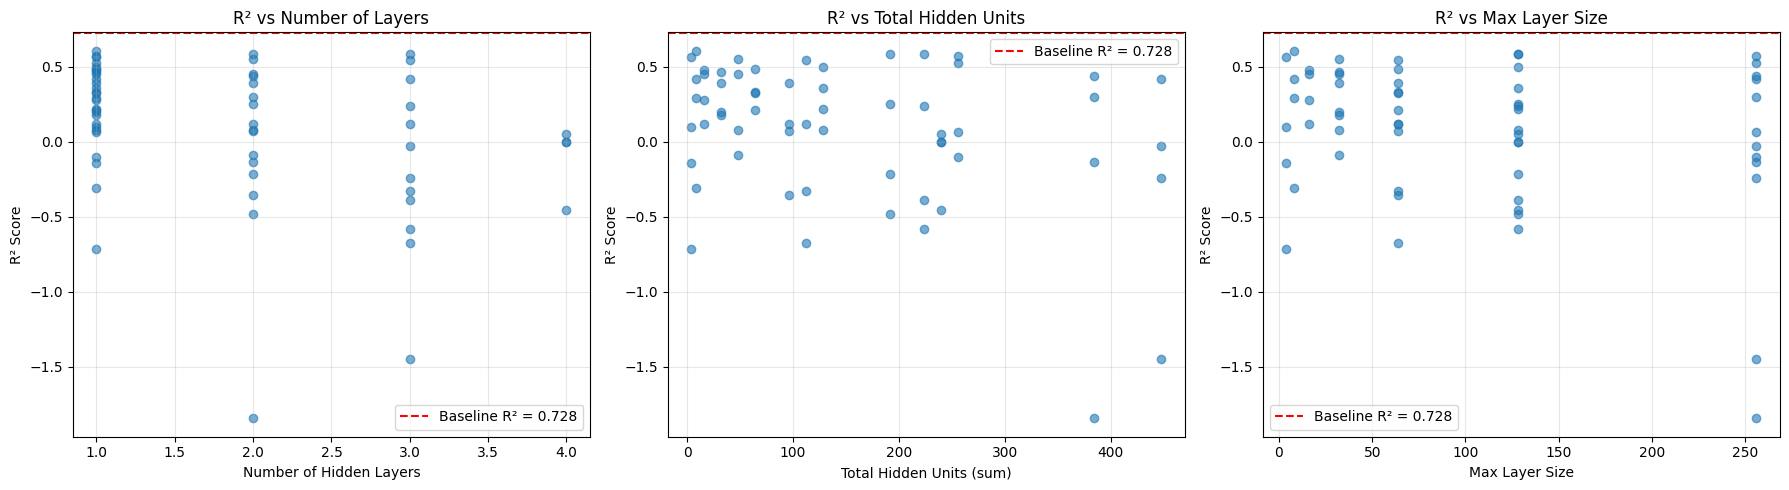

In [11]:
# Visualize performance vs architecture complexity
import matplotlib.pyplot as plt

mlp_results = results_extended[results_extended["model"] == "mlp"].copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# R² vs Layer Count
axes[0].scatter(mlp_results["layer_count"], mlp_results["r2"], alpha=0.6)
axes[0].axhline(y=baseline["r2"], color='r', linestyle='--', label=f'Baseline R² = {baseline["r2"]:.3f}')
axes[0].set_xlabel("Number of Hidden Layers")
axes[0].set_ylabel("R² Score")
axes[0].set_title("R² vs Number of Layers")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# R² vs Total Units
axes[1].scatter(mlp_results["total_units"], mlp_results["r2"], alpha=0.6)
axes[1].axhline(y=baseline["r2"], color='r', linestyle='--', label=f'Baseline R² = {baseline["r2"]:.3f}')
axes[1].set_xlabel("Total Hidden Units (sum)")
axes[1].set_ylabel("R² Score")
axes[1].set_title("R² vs Total Hidden Units")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# R² vs Max Layer Size
axes[2].scatter(mlp_results["max_layer_size"], mlp_results["r2"], alpha=0.6)
axes[2].axhline(y=baseline["r2"], color='r', linestyle='--', label=f'Baseline R² = {baseline["r2"]:.3f}')
axes[2].set_xlabel("Max Layer Size")
axes[2].set_ylabel("R² Score")
axes[2].set_title("R² vs Max Layer Size")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Layer size sweep

After testing 60+ neural network architectures (layer sizes from 4 to 256 units, depths from 1 to 4 layers), none beat the simple `poverty_lag1` baseline.

### The numbers
- **Baseline**: R² = 0.728, MSE = 45.94, MAE = 5.11
- **Best NN** (ELU, 8 units): R² = 0.608, MSE = 66.16, MAE = 6.48
- **Gap**: Baseline explains 12 percentage points more variance; NN errors are ~44% larger

### What this means
- The baseline is strong because poverty rates are highly persistent year-to-year — `poverty_lag1` captures most predictable signal.
- NNs are learning (R² = 0.608 is much better than random), but the additional features don't add enough beyond the lag.
- This is normal for small time-series datasets: simple models often outperform complex ones when temporal persistence dominates.

### Why NNs didn't help here
- **Small dataset**: limited training examples after time-splitting
- **Feature redundancy**: crime/health/population features correlate with poverty but don't add much beyond the lag
- **Overfitting**: larger/deeper networks performed worse (memorizing noise)
- **Temporal structure**: the baseline exploits year-to-year correlation more effectively

### Is this a problem?
No — it's informative. It tells us:
- `poverty_lag1` is a well-chosen baseline (strong predictor)
- The problem has strong temporal structure
- We'd need better features or more data, not just more complex models

The best NN (R² = 0.608) is still useful if we need non-linear relationships, but for forecasting, the simple lag feature is the better choice.

In [12]:
# Save extended results
OUT_PATH_EXTENDED = "../data/processed/results/poverty_nn_layer_size_sweep.csv"
results_extended.to_csv(OUT_PATH_EXTENDED, index=False)
print("Saved extended results:", OUT_PATH_EXTENDED)

Saved extended results: ../data/processed/results/poverty_nn_layer_size_sweep.csv
